# Ejercicio 4 (punto libre). De la convolución a la red convolucional

Curso de Inteligencia Artificial y Minirobots. Capítulo 5, Introducción a las Redes Neuronales Artificiales (José J. Martínez P.)

Ejercicio 5.9, numeral 4: *Punto libre.*

---

## 1. Planteamiento y justificación

La sección 5.8 del capítulo introduce las dos operaciones en las que se basa la visión por computador moderna, la **convolución** y el **max pooling**, y las ilustra con ejemplos numéricos, pero ninguno de los ejercicios anteriores las usa. Además, el Ejercicio 2 terminó con una limitación identificada: la red densa trata cada uno de los 784 píxeles como una característica independiente y no aprovecha que los píxeles vecinos están relacionados, y por eso confunde prendas de silueta parecida.

El punto libre se dedica a cerrar ese vacío, en cuatro partes:

1. **Implementar desde cero** la convolución y el max pooling con NumPy, y **verificarlas** contra los ejemplos numéricos del capítulo (figuras de la sección 5.8.1 y figura 5.23) y contra TensorFlow.
2. **Reproducir la figura 5.24** del capítulo: la imagen *Ascendente* de 512 × 512 después de un filtro vertical y un max pooling.
3. **Entrenar una red convolucional (CNN)** con Fashion MNIST y compararla con la red densa del Ejercicio 2 en las mismas condiciones.
4. **Abrir la red entrenada**: ver qué filtros aprendió y comprobar que su primera capa hace exactamente la operación implementada a mano.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import time
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.keras.utils.set_random_seed(2026)
plt.rcParams["axes.grid"] = False
np.set_printoptions(linewidth=120)
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## 2. La convolución implementada desde cero

Según el capítulo, una convolución es *un filtro de pesos que se usa para multiplicar un píxel por sus vecinos, para obtener un nuevo valor para ese píxel*. Para una imagen $I$ y un filtro $K$ de tamaño $f\times f$, cada elemento de la salida es la suma de los productos elemento a elemento entre el filtro y la submatriz de la imagen que cubre:

$$S(i,j) = \sum_{u=0}^{f-1}\sum_{v=0}^{f-1} I(i+u,\ j+v)\,K(u,v)$$

Si la imagen es de $n\times n$, el filtro recorre $n-f+1$ posiciones en cada dirección, y la salida es de $(n-f+1)\times(n-f+1)$. Para el ejemplo del capítulo, $6-3+1 = 4$.

Se programan dos versiones: una con ciclos, que sigue literalmente la descripción del capítulo (dividir la imagen en submatrices de 3 × 3 y multiplicar cada una por el filtro), y una vectorizada, necesaria para imágenes grandes.

In [2]:
def convolucion_ciclos(imagen, filtro):
    "Convolucion 'valida' con paso 1, tal como la describe el capitulo."
    n, f = imagen.shape[0], filtro.shape[0]
    salida = np.zeros((n - f + 1, n - f + 1))
    for i in range(n - f + 1):
        for j in range(n - f + 1):
            submatriz = imagen[i:i + f, j:j + f]
            salida[i, j] = np.sum(submatriz * filtro)
    return salida

def convolucion(imagen, filtro, relleno=0):
    "Version vectorizada. 'relleno' agrega ceros alrededor para conservar el tamano (padding)."
    if relleno:
        imagen = np.pad(imagen, relleno)
    ventanas = np.lib.stride_tricks.sliding_window_view(imagen, filtro.shape)
    return np.einsum("ijuv,uv->ij", ventanas, filtro)

imagen_cap = np.array([[3, 0, 1, 2, 7, 4],
                       [1, 5, 8, 9, 3, 1],
                       [2, 7, 2, 5, 1, 3],
                       [0, 1, 3, 1, 7, 8],
                       [4, 2, 1, 6, 2, 8],
                       [2, 4, 5, 2, 3, 9]], dtype=float)
filtro_vertical = np.array([[1, 0, -1],
                            [1, 0, -1],
                            [1, 0, -1]], dtype=float)
esperado_cap = np.array([[ -5, -4,  0,   8],
                         [-10, -2,  2,   3],
                         [  0, -2, -4,  -7],
                         [ -3, -2, -3, -16]], dtype=float)

S = convolucion_ciclos(imagen_cap, filtro_vertical)
print("Primer elemento, paso a paso como en el capitulo:")
sub = imagen_cap[:3, :3]
print("   submatriz =", sub.tolist())
print("   " + " + ".join(f"{int(a)}x{int(b)}" for a, b in zip(sub.T.ravel(), filtro_vertical.T.ravel())), "=", int(S[0, 0]))
print("\nResultado de la convolucion 6x6 * 3x3:")
print(S.astype(int))
print("\nCoincide con la matriz 4x4 del capitulo:", np.array_equal(S, esperado_cap))
print("La version vectorizada da lo mismo:     ", np.array_equal(convolucion(imagen_cap, filtro_vertical), S))

Primer elemento, paso a paso como en el capitulo:
   submatriz = [[3.0, 0.0, 1.0], [1.0, 5.0, 8.0], [2.0, 7.0, 2.0]]
   3x1 + 1x1 + 2x1 + 0x0 + 5x0 + 7x0 + 1x-1 + 8x-1 + 2x-1 = -5

Resultado de la convolucion 6x6 * 3x3:
[[ -5  -4   0   8]
 [-10  -2   2   3]
 [  0  -2  -4  -7]
 [ -3  -2  -3 -16]]

Coincide con la matriz 4x4 del capitulo: True
La version vectorizada da lo mismo:      True


Las dos implementaciones reproducen exactamente la matriz 4 × 4 del capítulo. En el desarrollo del primer elemento, el capítulo imprime la primera submatriz con un 1 en la esquina inferior derecha, aunque el cálculo que muestra usa el valor correcto de la imagen, que es 2 (fila 3, columna 3); el resultado, −5, es el mismo.

### 2.1 Comparación con SciPy y TensorFlow

Hay un detalle de nomenclatura que conviene aclarar. En matemáticas, la convolución **invierte** el filtro (lo rota 180°) antes de recorrer la imagen; la operación sin inversión se llama **correlación cruzada**. Lo que el capítulo llama convolución, y lo que implementan todas las librerías de redes neuronales, es la correlación cruzada. Como los filtros de una CNN se aprenden, la diferencia no importa en la práctica: la red simplemente aprende el filtro ya invertido. Se verifica con SciPy, que ofrece las dos operaciones, y con TensorFlow:

In [3]:
from scipy.signal import correlate2d, convolve2d

corr_scipy = correlate2d(imagen_cap, filtro_vertical, mode="valid")
conv_scipy = convolve2d(imagen_cap, filtro_vertical, mode="valid")
conv_tf = tf.nn.conv2d(imagen_cap[None, :, :, None], filtro_vertical[:, :, None, None],
                       strides=1, padding="VALID").numpy()[0, :, :, 0]

print("scipy correlate2d (correlacion cruzada) igual al capitulo:", np.array_equal(corr_scipy, esperado_cap))
print("tf.nn.conv2d igual al capitulo:                            ", np.allclose(conv_tf, esperado_cap))
print("scipy convolve2d (convolucion matematica) igual al capitulo:", np.array_equal(conv_scipy, esperado_cap))
print("\nconvolve2d invierte el filtro; con este filtro antisimetrico eso cambia el signo:")
print(conv_scipy.astype(int))

scipy correlate2d (correlacion cruzada) igual al capitulo: True
tf.nn.conv2d igual al capitulo:                             True
scipy convolve2d (convolucion matematica) igual al capitulo: False

convolve2d invierte el filtro; con este filtro antisimetrico eso cambia el signo:
[[ 5  4  0 -8]
 [10  2 -2 -3]
 [ 0  2  4  7]
 [ 3  2  3 16]]


### 2.2 Por qué este filtro detecta bordes verticales

El filtro tiene una columna de unos a la izquierda y una de menos unos a la derecha, así que mide la diferencia de intensidad entre el lado izquierdo y el derecho de cada vecindario. Donde la imagen es uniforme, las dos columnas se cancelan y el resultado es cero; donde hay un cambio brusco de izquierda a derecha, el resultado es grande. Se comprueba con una imagen claramente dividida en dos mitades:

Imagen:
[[10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]
 [10 10 10  0  0  0]]

Despues del filtro vertical:
[[ 0 30 30  0]
 [ 0 30 30  0]
 [ 0 30 30  0]
 [ 0 30 30  0]]


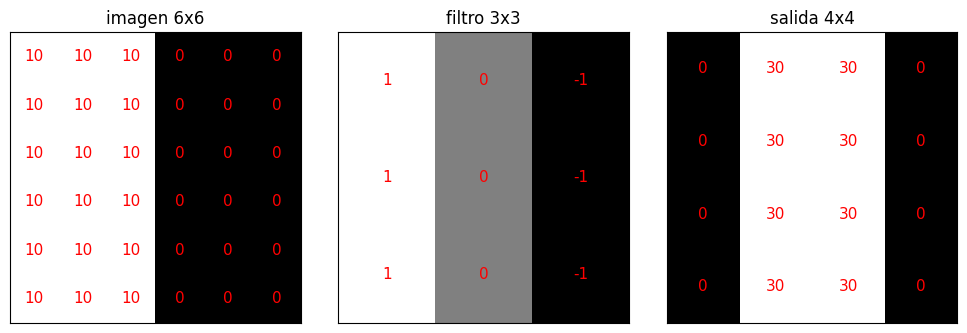

In [4]:
mitades = np.array([[10, 10, 10, 0, 0, 0]] * 6, dtype=float)
borde = convolucion(mitades, filtro_vertical)
print("Imagen:"); print(mitades.astype(int))
print("\nDespues del filtro vertical:"); print(borde.astype(int))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.3))
for a, m, t in zip(ax, (mitades, filtro_vertical, borde), ("imagen 6x6", "filtro 3x3", "salida 4x4")):
    a.imshow(m, cmap="gray"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
    for (r, c), v in np.ndenumerate(m):
        a.text(c, r, int(v), ha="center", va="center", color="red", fontsize=11)
plt.tight_layout(); plt.show()

La salida vale cero en las zonas uniformes y 30 en la franja central, justo donde está el borde. Esta es la idea de los **detectores locales** de la sección 5.8.1: un filtro pequeño que responde con fuerza a un patrón específico, donde sea que este aparezca en la imagen.

## 3. Max pooling implementado desde cero

El max pooling divide la imagen en bloques (*pools*) de 2 × 2 y conserva solo el máximo de cada uno, lo que reduce el número de píxeles en un 75 %. Se verifica con el ejemplo de la figura 5.23 del capítulo.

In [5]:
def max_pooling(imagen, tam=2):
    "Max pooling con ventanas de tam x tam sin traslape. Recorta filas/columnas sobrantes."
    h, w = (imagen.shape[0] // tam) * tam, (imagen.shape[1] // tam) * tam
    bloques = imagen[:h, :w].reshape(h // tam, tam, w // tam, tam)
    return bloques.max(axis=(1, 3))

fig523 = np.array([[  0,  64, 128, 128],
                   [ 48, 192, 144, 144],
                   [142, 226, 168,   0],
                   [255,   0,   0,  64]], dtype=float)
esperado_523 = np.array([[192, 144],
                         [255, 168]], dtype=float)

P = max_pooling(fig523)
P_tf = tf.keras.layers.MaxPooling2D(2)(fig523[None, :, :, None]).numpy()[0, :, :, 0]
print("Resultado:"); print(P.astype(int))
print("Coincide con la figura 5.23:", np.array_equal(P, esperado_523))
print("Coincide con MaxPooling2D de Keras:", np.array_equal(P, P_tf))

Resultado:
[[192 144]
 [255 168]]
Coincide con la figura 5.23: True
Coincide con MaxPooling2D de Keras: True


## 4. Reproducción de la figura 5.24: la imagen *Ascendente*

La figura 5.24 del capítulo proviene del libro de Moroney citado en la bibliografía, que usa la imagen de prueba *ascent* de SciPy (512 × 512 píxeles en escala de grises). Se aplica el mismo procedimiento: un filtro para resaltar líneas verticales, recorte de los valores a $[0, 255]$ y max pooling de 2 × 2. Se usa relleno de ceros (*padding*) de un píxel para que el filtrado conserve el tamaño de 512 × 512, y así el pooling produce exactamente la imagen de 256 × 256 que menciona el capítulo.

El filtro que usa Moroney para líneas verticales es el de Sobel, una versión del filtro del capítulo que da más peso a la fila central:
$$K = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1\end{bmatrix}$$

Se comparan los dos filtros, el de Sobel y el del capítulo. En Colab la imagen se descarga automáticamente con `scipy.datasets` (requiere el paquete `pooch`, que viene preinstalado).

Imagen original: (512, 512)
Filtrada: (512, 512)   Despues del max pooling: (256, 256)   (0.02 s)


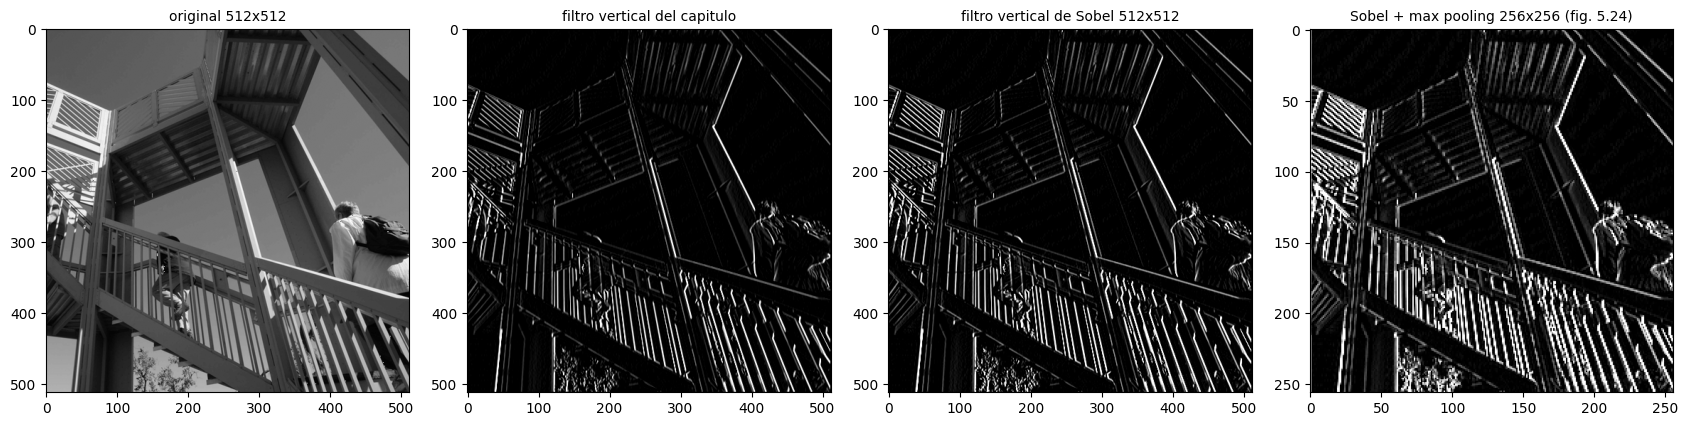

In [6]:
try:
    from scipy import datasets
    ascent = datasets.ascent().astype(float)
except Exception:
    from scipy import misc                     # versiones antiguas de SciPy
    ascent = misc.ascent().astype(float)
print("Imagen original:", ascent.shape)

sobel_vertical = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)

t0 = time.time()
filtrada_sobel = np.clip(convolucion(ascent, sobel_vertical, relleno=1), 0, 255)
filtrada_cap   = np.clip(convolucion(ascent, -filtro_vertical, relleno=1), 0, 255)
reducida = max_pooling(filtrada_sobel)
print(f"Filtrada: {filtrada_sobel.shape}   Despues del max pooling: {reducida.shape}   ({time.time() - t0:.2f} s)")

fig, ax = plt.subplots(1, 4, figsize=(17, 4.6))
for a, img, t in zip(ax, (ascent, filtrada_cap, filtrada_sobel, reducida),
                     ("original 512x512", "filtro vertical del capitulo", "filtro vertical de Sobel 512x512",
                      "Sobel + max pooling 256x256 (fig. 5.24)")):
    a.imshow(img, cmap="gray"); a.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()

Las líneas verticales de la escalera y la baranda quedan resaltadas y las horizontales prácticamente desaparecen. Después del max pooling la imagen tiene la cuarta parte de los píxeles y, como afirma el capítulo, los rasgos filtrados se conservan e incluso se intensifican, porque de cada bloque de 2 × 2 se retiene la respuesta más fuerte del detector. El filtro del capítulo produce un resultado muy parecido al de Sobel (se usa con signo invertido para resaltar los bordes de oscuro a claro, igual que Sobel).

Hasta aquí los filtros se diseñaron a mano. La propuesta de una CNN es **aprenderlos**: en lugar de elegir $K$, se tratan sus nueve valores como pesos y se ajustan por retropropagación, igual que los pesos $W$ de una capa densa.

## 5. Red convolucional para Fashion MNIST

### 5.1 Datos

Se usan los mismos datos y la misma división del Ejercicio 2 (50 000 de entrenamiento, 10 000 de validación, 10 000 de prueba). La única diferencia es que las imágenes conservan su forma de matriz y se les agrega una dimensión de canal, porque las capas convolucionales esperan entradas de la forma (alto, ancho, canales); una imagen en escala de grises tiene un canal.

In [7]:
(x_full, y_full), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_full = (x_full.astype("float32") / 255.0)[..., None]      # (60000, 28, 28, 1)
x_test = (x_test.astype("float32") / 255.0)[..., None]
x_train, y_train = x_full[:50_000], y_full[:50_000]
x_val,   y_val   = x_full[50_000:], y_full[50_000:]
nombres = ["Camiseta/top", "Pantalon", "Buzo", "Vestido", "Abrigo",
           "Sandalia", "Camisa", "Tenis", "Bolso", "Botin"]
print("Entrenamiento", x_train.shape, " Validacion", x_val.shape, " Prueba", x_test.shape)

Entrenamiento (50000, 28, 28, 1)  Validacion (10000, 28, 28, 1)  Prueba (10000, 28, 28, 1)


### 5.2 Arquitectura

In [8]:
tf.keras.utils.set_random_seed(2026)
cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv1"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool1"),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool2"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")
], name="cnn")
cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**Funciones nuevas respecto al Ejercicio 2.**

- **`Conv2D(32, (3, 3), activation="relu")`** aplica 32 filtros de 3 × 3 distintos a la imagen, cada uno con la operación de la sección 2, le suma un sesgo y aplica ReLU. El resultado son 32 *mapas de características* de 26 × 26 (28 − 3 + 1 = 26). Los 9 valores de cada filtro son pesos entrenables.
- **`MaxPooling2D((2, 2))`** aplica el max pooling de la sección 3 a cada mapa: 26 × 26 → 13 × 13. No tiene pesos.
- La segunda convolución aplica 64 filtros, cada uno de 3 × 3 × 32, porque combina los 32 mapas anteriores: 13 → 11 y, tras el pooling, 11 → 5.
- **`Flatten`** convierte los 64 mapas de 5 × 5 en un vector de 1 600 valores, que las capas densas clasifican como en el Ejercicio 2.

**Conteo de parámetros**, que coincide con `summary()`:

| Capa | Cálculo | Parámetros |
|---|---|--:|
| conv1 | $3\cdot3\cdot1\cdot32 + 32$ | 320 |
| conv2 | $3\cdot3\cdot32\cdot64 + 64$ | 18 496 |
| densa | $1600\cdot128 + 128$ | 204 928 |
| salida | $128\cdot10 + 10$ | 1 290 |
| **Total** | | **225 034** |

La primera capa convolucional tiene solo 320 parámetros frente a los 100 480 de la primera capa de la red densa. La razón es el **peso compartido**: el mismo filtro de 9 pesos se aplica en todas las posiciones de la imagen, en lugar de tener un peso independiente por cada píxel y cada neurona. Esto refleja la intuición de la sección 5.8: un borde es un borde en cualquier lugar de la imagen, así que el detector no necesita aprenderse por separado en cada posición.

### 5.3 Entrenamiento

Se entrenan en las mismas condiciones la CNN y la red densa regularizada del Ejercicio 2, para que la comparación sea justa: mismo optimizador, misma pérdida, mismo tamaño de lote, parada temprana con los mismos criterios. En CPU la CNN tarda unos 20 a 30 segundos por época; en Colab con GPU, unos pocos segundos.

In [9]:
def entrenar(modelo, epocas):
    modelo.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    parada = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    t0 = time.time()
    h = modelo.fit(x_train, y_train, epochs=epocas, batch_size=64, validation_data=(x_val, y_val),
                   callbacks=[parada], verbose=2)
    return h, time.time() - t0

hist_cnn, t_cnn = entrenar(cnn, 15)

tf.keras.utils.set_random_seed(2026)
densa = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
], name="densa_ejercicio_2")
hist_densa, t_densa = entrenar(densa, 40)

Epoch 1/15


782/782 - 13s - 16ms/step - accuracy: 0.7954 - loss: 0.5667 - val_accuracy: 0.8595 - val_loss: 0.3791


Epoch 2/15


782/782 - 20s - 26ms/step - accuracy: 0.8648 - loss: 0.3706 - val_accuracy: 0.8836 - val_loss: 0.3217


Epoch 3/15


...

782/782 - 3s - 3ms/step - accuracy: 0.8969 - loss: 0.2765 - val_accuracy: 0.8873 - val_loss: 0.3203


Epoch 12/40


782/782 - 3s - 3ms/step - accuracy: 0.8978 - loss: 0.2716 - val_accuracy: 0.8862 - val_loss: 0.3176


Epoch 13/40


782/782 - 2s - 3ms/step - accuracy: 0.9015 - loss: 0.2648 - val_accuracy: 0.8883 - val_loss: 0.3185


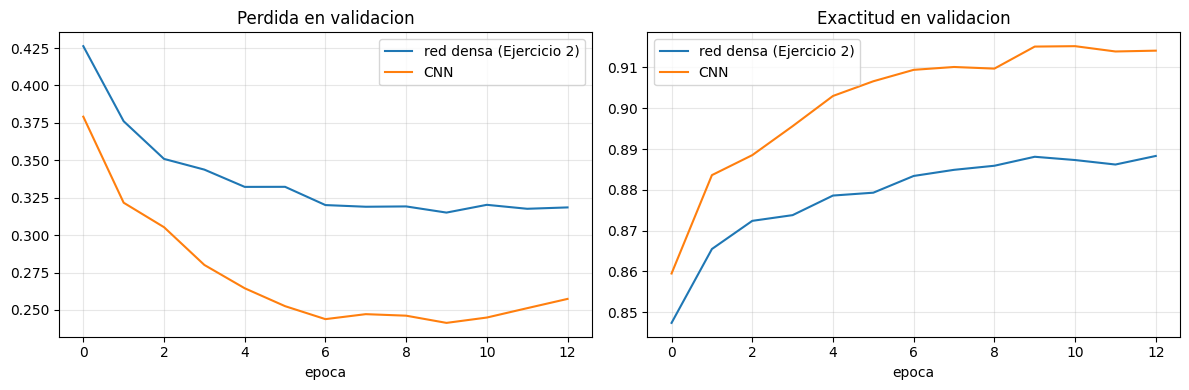

Modelo                      Parametros  Epocas   Tiempo   Perdida  Exactitud
----------------------------------------------------------------------------


densa_ejercicio_2              101,770      13      33s    0.3388     0.8801


cnn                            225,034      13     202s    0.2648     0.9106

La CNN reduce el error de prueba de 11.99% a 8.94%: 25% menos errores.


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for h, nombre in ((hist_densa, "red densa (Ejercicio 2)"), (hist_cnn, "CNN")):
    ax[0].plot(h.history["val_loss"], label=nombre)
    ax[1].plot(h.history["val_accuracy"], label=nombre)
ax[0].set_title("Perdida en validacion"); ax[1].set_title("Exactitud en validacion")
for a in ax:
    a.set_xlabel("epoca"); a.legend(); a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'Modelo':<26}{'Parametros':>12}{'Epocas':>8}{'Tiempo':>9}{'Perdida':>10}{'Exactitud':>11}")
print("-" * 76)
res = {}
for m, h, t in ((densa, hist_densa, t_densa), (cnn, hist_cnn, t_cnn)):
    l, a = m.evaluate(x_test, y_test, verbose=0)
    res[m.name] = (m.predict(x_test, verbose=0).argmax(1), a)
    print(f"{m.name:<26}{m.count_params():>12,}{len(h.history['loss']):>8}{t:>8.0f}s{l:>10.4f}{a:>11.4f}")
ea, eb = 1 - res["densa_ejercicio_2"][1], 1 - res["cnn"][1]
print(f"\nLa CNN reduce el error de prueba de {ea:.2%} a {eb:.2%}: {1 - eb/ea:.0%} menos errores.")

### 5.4 ¿Dónde mejora la CNN?

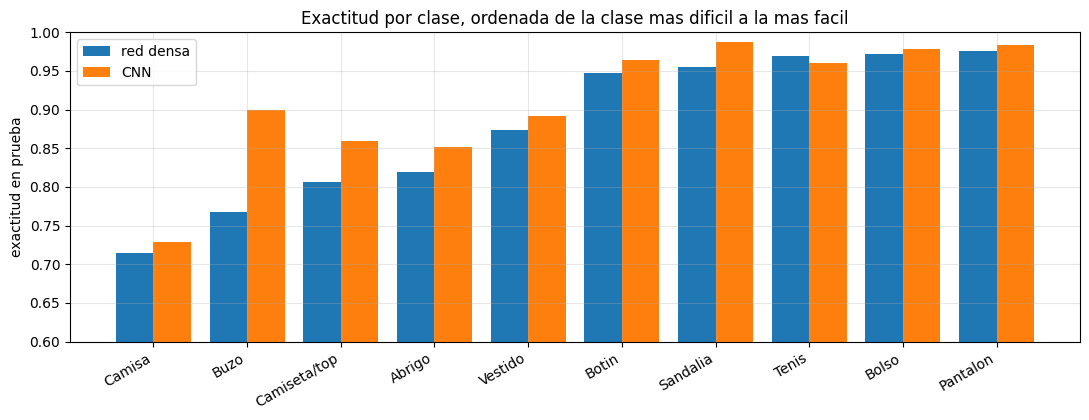

Clase             Densa     CNN   Mejora
Camisa            0.714   0.729   +0.015
Buzo              0.768   0.900   +0.132
Camiseta/top      0.806   0.859   +0.053
Abrigo            0.820   0.852   +0.032
Vestido           0.874   0.892   +0.018
Botin             0.947   0.964   +0.017
Sandalia          0.955   0.988   +0.033
Tenis             0.969   0.960   -0.009
Bolso             0.972   0.979   +0.007
Pantalon          0.976   0.983   +0.007


In [11]:
def exactitud_por_clase(pred):
    return np.array([np.mean(pred[y_test == c] == c) for c in range(10)])

acc_d = exactitud_por_clase(res["densa_ejercicio_2"][0])
acc_c = exactitud_por_clase(res["cnn"][0])

orden = np.argsort(acc_d)
fig, ax = plt.subplots(figsize=(11, 4.3))
x = np.arange(10)
ax.bar(x - 0.2, acc_d[orden], 0.4, label="red densa")
ax.bar(x + 0.2, acc_c[orden], 0.4, label="CNN")
ax.set_xticks(x); ax.set_xticklabels([nombres[i] for i in orden], rotation=30, ha="right")
ax.set_ylim(0.6, 1.0); ax.set_ylabel("exactitud en prueba"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title("Exactitud por clase, ordenada de la clase mas dificil a la mas facil")
plt.tight_layout(); plt.show()

print(f"{'Clase':<15}{'Densa':>8}{'CNN':>8}{'Mejora':>9}")
for c in orden:
    print(f"{nombres[c]:<15}{acc_d[c]:>8.3f}{acc_c[c]:>8.3f}{acc_c[c] - acc_d[c]:>+9.3f}")

La mejora no es uniforme. Las clases fáciles (pantalón, bolso, botín) ya estaban cerca del techo y apenas cambian, y una de ellas incluso baja una décima (tenis). La ganancia mayor, con diferencia, es la de **Buzo**: +13.2 puntos, de 76.8 % a 90.0 %. Le siguen **Camiseta/top** (+5.3), **Sandalia** (+3.3) y **Abrigo** (+3.2). Son prendas que la red densa confundía entre sí y que se distinguen por detalles locales, como el largo y la forma de la manga o el corte del cuello, que es justamente lo que detectan los filtros convolucionales.

El resultado que no se esperaba es el de **Camisa**: sigue siendo con mucho la clase más difícil (72.9 %) y solo mejora 1.5 puntos, mientras que su vecina Buzo gana casi diez veces más. Esto indica que buena parte de su error no se debe a la arquitectura sino a los propios datos: como se vio en el Ejercicio 2, muchas camisas son, a 28 × 28 píxeles, prácticamente indistinguibles de una camiseta, un buzo o un abrigo, y en algunos casos el rótulo es discutible. Una red más capaz no puede recuperar información que la imagen no contiene.

## 6. Dentro de la red entrenada

### 6.1 Los filtros aprendidos por la primera capa

Forma de los filtros de conv1: (3, 3, 1, 32)   sesgos: (32,)


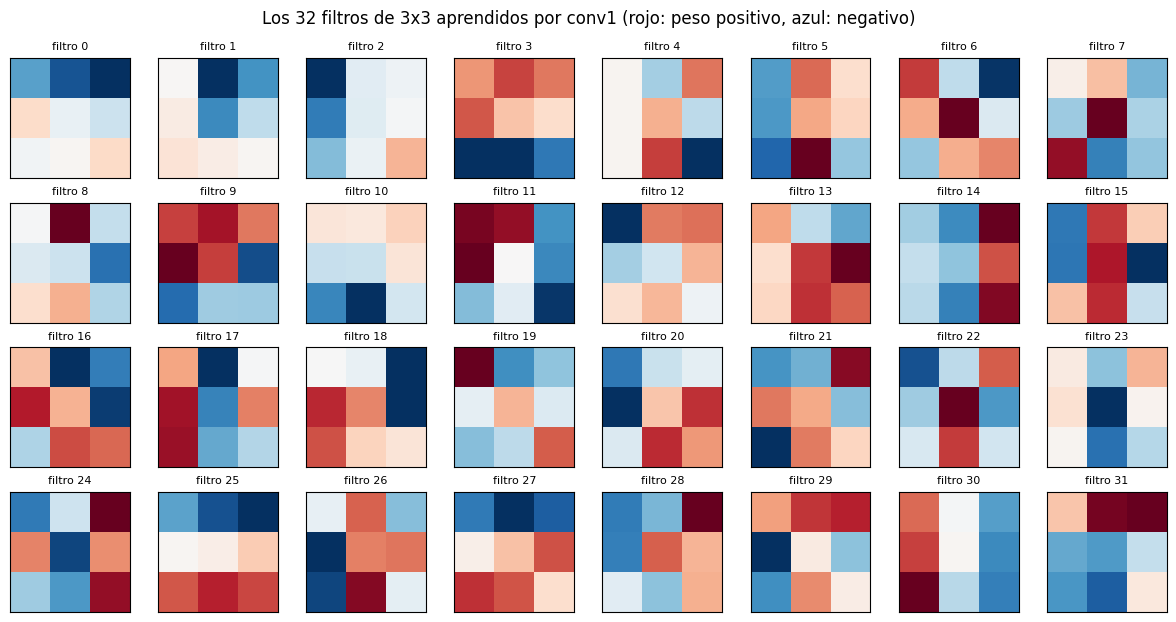

Filtro mas parecido a un detector de borde vertical (capitulo): filtro 30, correlacion +0.96
Filtro mas parecido a un detector de borde horizontal: filtro 25, correlacion -0.97


In [12]:
K1, b1 = cnn.get_layer("conv1").get_weights()          # K1: (3, 3, 1, 32)
print("Forma de los filtros de conv1:", K1.shape, "  sesgos:", b1.shape)

fig, ax = plt.subplots(4, 8, figsize=(12, 6.3))
for k, a in enumerate(ax.ravel()):
    f = K1[:, :, 0, k]
    lim = np.abs(f).max()
    a.imshow(f, cmap="RdBu_r", vmin=-lim, vmax=lim); a.set_xticks([]); a.set_yticks([])
    a.set_title(f"filtro {k}", fontsize=8)
plt.suptitle("Los 32 filtros de 3x3 aprendidos por conv1 (rojo: peso positivo, azul: negativo)")
plt.tight_layout(); plt.show()

# Cual filtro aprendido se parece mas a los detectores de bordes disenados a mano?
def similitud(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(np.sum(a * b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))
for nombre, ref in (("borde vertical (capitulo)", filtro_vertical), ("borde horizontal", filtro_vertical.T)):
    sims = [similitud(K1[:, :, 0, k], ref) for k in range(32)]
    k = int(np.argmax(np.abs(sims)))
    print(f"Filtro mas parecido a un detector de {nombre}: filtro {k}, correlacion {sims[k]:+.2f}")

Nadie le indicó a la red qué filtros usar; los 32 filtros partieron de valores aleatorios. Aun así, varios de ellos tienen la estructura de un detector de bordes, con una zona positiva y una negativa enfrentadas, en distintas orientaciones. La correlación con los filtros diseñados a mano lo confirma: hay un filtro aprendido con correlación de 0.96 con el detector de bordes verticales del capítulo, y otro con correlación de −0.97 (el mismo patrón con el signo invertido) con el detector de bordes horizontales. Es lo que ilustra la figura 5.21 del capítulo: las primeras capas aprenden rasgos simples y genéricos (bordes, contrastes), y las siguientes los combinan en rasgos más complejos.

### 6.2 Mapas de características

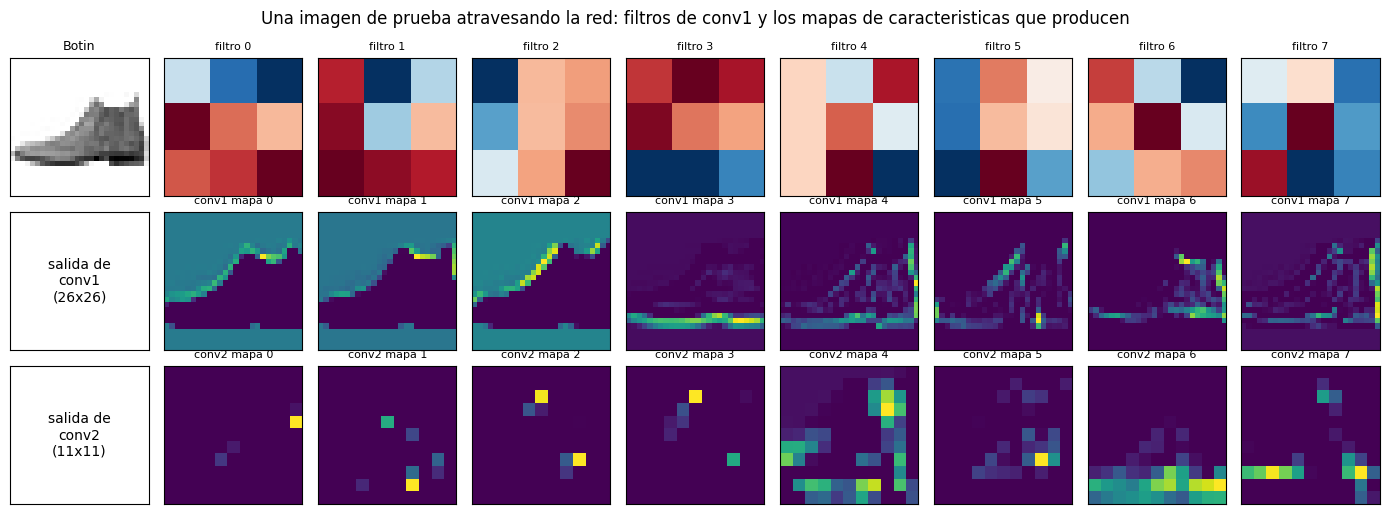

In [13]:
extractor = tf.keras.Model(inputs=cnn.inputs,
                           outputs=[cnn.get_layer("conv1").output, cnn.get_layer("conv2").output])
idx = 0
m1, m2 = extractor(x_test[idx:idx + 1])
m1, m2 = m1.numpy()[0], m2.numpy()[0]

fig, ax = plt.subplots(3, 9, figsize=(14, 5.2))
ax[0, 0].imshow(x_test[idx, :, :, 0], cmap="gray_r"); ax[0, 0].set_title(nombres[y_test[idx]], fontsize=9)
for k in range(8):
    ax[0, k + 1].imshow(K1[:, :, 0, k], cmap="RdBu_r"); ax[0, k + 1].set_title(f"filtro {k}", fontsize=8)
    ax[1, k + 1].imshow(m1[:, :, k], cmap="viridis"); ax[1, k + 1].set_title(f"conv1 mapa {k}", fontsize=8)
    ax[2, k + 1].imshow(m2[:, :, k], cmap="viridis"); ax[2, k + 1].set_title(f"conv2 mapa {k}", fontsize=8)
ax[1, 0].text(0.5, 0.5, "salida de\nconv1\n(26x26)", ha="center", va="center")
ax[2, 0].text(0.5, 0.5, "salida de\nconv2\n(11x11)", ha="center", va="center")
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.suptitle("Una imagen de prueba atravesando la red: filtros de conv1 y los mapas de caracteristicas que producen")
plt.tight_layout(); plt.show()

Cada mapa de `conv1` resalta un aspecto distinto del mismo botín: algunos responden al fondo y al contorno superior de la prenda, otro se activa casi solo en la suela (el borde inferior), otro en el borde derecho y otros en la textura interior. Los mapas de `conv2`, de menor resolución, ya no se parecen a la imagen: combinan los mapas anteriores y responden a patrones más abstractos que la red encontró útiles para clasificar.

### 6.3 Verificación: la primera capa hace la operación programada a mano

Como cierre, se comprueba que `Conv2D` realiza exactamente la operación implementada en la sección 2. Se toma una imagen de prueba, se le aplica cada uno de los 32 filtros aprendidos con la función `convolucion` escrita en NumPy, se suma el sesgo, se aplica ReLU y se compara con la salida real de la capa `conv1`.

In [14]:
imagen = x_test[idx, :, :, 0].astype(np.float64)
manual = np.stack([np.maximum(0, convolucion(imagen, K1[:, :, 0, k].astype(np.float64)) + b1[k])
                   for k in range(32)], axis=-1)
print("Forma de la salida calculada a mano:", manual.shape, "  forma de la salida de Keras:", m1.shape)
print("Diferencia maxima:", np.abs(manual - m1).max())

Forma de la salida calculada a mano: (26, 26, 32)   forma de la salida de Keras: (26, 26, 32)
Diferencia maxima: 7.812602875745256e-08


La diferencia máxima es del orden de $10^{-7}$, el redondeo de la precisión simple con la que trabaja TensorFlow. La capa convolucional de Keras es, exactamente, la convolución del capítulo seguida de la suma del sesgo y la función de activación, igual que una neurona artificial de la sección 5.2.2 en la que las entradas son los nueve píxeles de un vecindario.

## 7. Conclusiones

1. **Las implementaciones propias reproducen todos los ejemplos numéricos de la sección 5.8.** La convolución da la matriz 4 × 4 del capítulo y el max pooling da la matriz 2 × 2 de la figura 5.23, en ambos casos idénticas a las de SciPy y TensorFlow. Se aclaró además que la operación que el capítulo y las librerías llaman convolución es, en rigor, una correlación cruzada.
2. **Se reprodujo la figura 5.24.** El filtro vertical resalta las líneas verticales de la imagen *Ascendente* y el max pooling reduce la imagen de 512 × 512 a 256 × 256 conservando esos rasgos.
3. **La CNN supera a la red densa del Ejercicio 2**: 91.1 % de exactitud de prueba frente a 88.0 %, lo que elimina una cuarta parte de sus errores. La mejora se concentra en buzos, camisetas, sandalias y abrigos. Lo logra con una primera capa de solo 320 parámetros gracias al peso compartido: el mismo detector se aplica en todas las posiciones de la imagen. La clase *Camisa* casi no mejora, lo que señala un límite de los datos y no del modelo.
4. **Los filtros que aprende la red se parecen a los que diseñaría una persona.** Partiendo de valores aleatorios, varios filtros de la primera capa terminaron con la estructura de detectores de bordes (correlaciones de +0.96 y −0.97 con los filtros del capítulo), lo que ilustra la afirmación del capítulo de que con *Deep Learning* los rasgos se aprenden implícitamente.
5. **Una capa convolucional no es una caja negra.** Su salida se reprodujo a mano con la función de convolución de 10 líneas escrita al comienzo, más un sesgo y una ReLU. La red convolucional usa las mismas piezas que el resto del capítulo, la neurona artificial, la función de activación y la retropropagación, organizadas de forma que aprovechan la estructura espacial de la imagen.